In [2]:
import os
print(os.getcwd())

E:\mutual-fund-data-project


In [5]:
nav = pd.read_csv("Data/Processed/02_nav_history_cleaned.csv")
transactions = pd.read_csv("Data/Processed/08_investor_transactions_cleaned.csv")
performance = pd.read_csv("Data/Processed/07_scheme_performance_cleaned.csv")

In [6]:
print("NAV Shape:", nav.shape)
print("Transactions Shape:", transactions.shape)
print("Performance Shape:", performance.shape)

NAV Shape: (46000, 3)
Transactions Shape: (32778, 13)
Performance Shape: (41, 19)


In [7]:
nav.head()

,amfi_code,date,nav
0,100016,2022-01-03,520.4608
1,100016,2022-01-04,515.0971
2,100016,2022-01-05,521.7239
3,100016,2022-01-06,515.7880
4,100016,2022-01-07,515.1639


In [9]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go

plt.style.use("ggplot")

print("Libraries Imported Successfully")

Libraries Imported Successfully


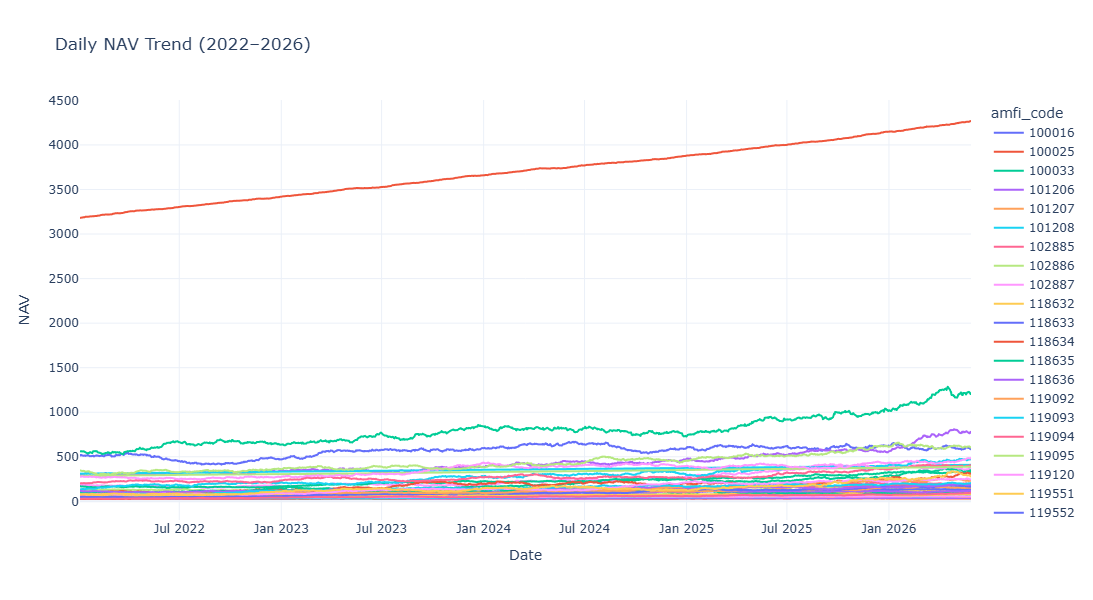

In [10]:
# Convert date column to datetime
nav["date"] = pd.to_datetime(nav["date"])

# Plot daily NAV for all schemes
fig = px.line(
    nav,
    x="date",
    y="nav",
    color="amfi_code",
    title="Daily NAV Trend (2022–2026)"
)

fig.update_layout(
    xaxis_title="Date",
    yaxis_title="NAV",
    template="plotly_white",
    height=600
)

fig.show()

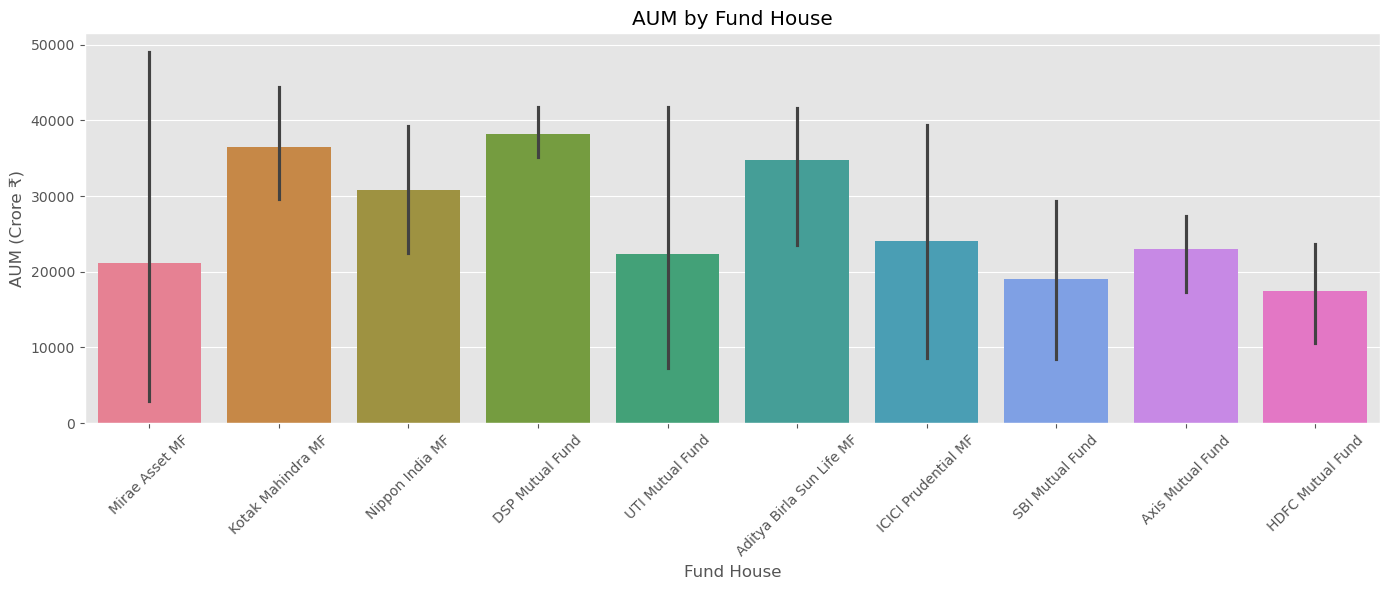

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns

# Sort by AUM
aum_data = performance.sort_values(by="aum_crore", ascending=False)

plt.figure(figsize=(14,6))

sns.barplot(
    data=aum_data,
    x="fund_house",
    y="aum_crore",
    hue="fund_house",
    legend=False
)

plt.title("AUM by Fund House")
plt.xlabel("Fund House")
plt.ylabel("AUM (Crore ₹)")
plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

In [15]:
transactions.columns

Index(['investor_id', 'transaction_date', 'amfi_code', 'transaction_type',
       'amount_inr', 'state', 'city', 'city_tier', 'age_group', 'gender',
       'annual_income_lakh', 'payment_mode', 'kyc_status'],
      dtype='object')

In [16]:
# Convert transaction date to datetime
transactions["transaction_date"] = pd.to_datetime(transactions["transaction_date"])

# Filter only SIP transactions
sip = transactions[transactions["transaction_type"] == "SIP"]

# Monthly SIP inflow
monthly_sip = sip.groupby(
    pd.Grouper(key="transaction_date", freq="ME")
)["amount_inr"].sum().reset_index()

monthly_sip.head()

,transaction_date,amount_inr
0,2024-01-31,12635349
1,2024-02-29,12613376
2,2024-03-31,12088413
3,2024-04-30,13512385
4,2024-05-31,13218606


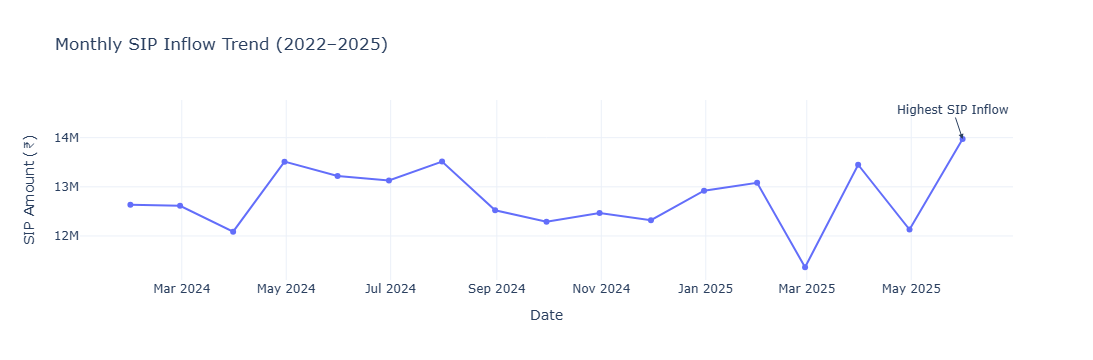

In [18]:
fig = px.line(
    monthly_sip,
    x="transaction_date",
    y="amount_inr",
    title="Monthly SIP Inflow Trend (2022–2025)",
    markers=True
)

fig.update_layout(
    xaxis_title="Date",
    yaxis_title="SIP Amount (₹)",
    template="plotly_white"
)

# Mark highest SIP inflow point
max_row = monthly_sip.loc[monthly_sip["amount_inr"].idxmax()]

fig.add_annotation(
    x=max_row["transaction_date"],
    y=max_row["amount_inr"],
    text="Highest SIP Inflow",
    showarrow=True,
    arrowhead=2
)



fig.show()

In [20]:
print(transactions["amfi_code"].dtype)
print(performance["amfi_code"].dtype)

int64
object


In [21]:
transactions["amfi_code"] = transactions["amfi_code"].astype(str)
performance["amfi_code"] = performance["amfi_code"].astype(str)

In [22]:
heatmap_data = transactions.merge(
    performance[["amfi_code", "category"]],
    on="amfi_code",
    how="left"
)

In [23]:
print(transactions["amfi_code"].dtype)
print(performance["amfi_code"].dtype)

print(transactions["amfi_code"].head())
print(performance["amfi_code"].head())

object
object
0    119092
1    148567
2    118636
3    118634
4    119094
Name: amfi_code, dtype: object
0    119551
1    119552
2    119598
3    119599
4    119120
Name: amfi_code, dtype: object


In [24]:
print(transactions["amfi_code"].head())
print(performance["amfi_code"].head())

print(transactions["amfi_code"].apply(type).unique())
print(performance["amfi_code"].apply(type).unique())

0    119092
1    148567
2    118636
3    118634
4    119094
Name: amfi_code, dtype: object
0    119551
1    119552
2    119598
3    119599
4    119120
Name: amfi_code, dtype: object
[<class 'str'>]
[<class 'str'>]


In [25]:
transactions["amfi_code"] = transactions["amfi_code"].astype(str).str.strip()
performance["amfi_code"] = performance["amfi_code"].astype(str).str.strip()

In [26]:
heatmap_data = transactions.merge(
    performance[["amfi_code", "category"]],
    on="amfi_code",
    how="left"
)

In [27]:
print(transactions.dtypes)
print()
print(performance.dtypes)

investor_id                   object
transaction_date      datetime64[ns]
amfi_code                     object
transaction_type              object
amount_inr                     int64
state                         object
city                          object
city_tier                     object
age_group                     object
gender                        object
annual_income_lakh           float64
payment_mode                  object
kyc_status                    object
dtype: object

amfi_code              object
scheme_name            object
fund_house             object
category               object
plan                   object
return_1yr_pct        float64
return_3yr_pct        float64
return_5yr_pct        float64
benchmark_3yr_pct     float64
alpha                 float64
beta                  float64
sharpe_ratio          float64
sortino_ratio         float64
std_dev_ann_pct       float64
max_drawdown_pct      float64
aum_crore             float64
expense_ratio_pct     fl

In [28]:
heatmap_data = transactions.merge(
    performance[["amfi_code", "category"]],
    on="amfi_code",
    how="left"
)

print("Merge Successful!")
print(heatmap_data.head())

Merge Successful!
  investor_id transaction_date amfi_code transaction_type  amount_inr  \
0   INV003054       2024-01-01    119092              SIP        1834   
1   INV002952       2024-01-01    148567       Redemption      392882   
2   INV003420       2024-01-01    118636              SIP         912   
3   INV003436       2024-01-01    118634              SIP        1102   
4   INV004691       2024-01-01    119094          Lumpsum        8682   

         state       city city_tier age_group  gender  annual_income_lakh  \
0    Telangana  Hyderabad       T30       56+  Female                77.1   
1       Punjab   Amritsar       B30     18-25    Male                 7.1   
2      Haryana  Faridabad       B30     36-45    Male                47.2   
3  Maharashtra     Mumbai       T30     36-45  Female                54.4   
4        Delhi      Noida       T30     26-35    Male                14.5   

  payment_mode kyc_status   category  
0          UPI   Verified  Large Cap  
1 

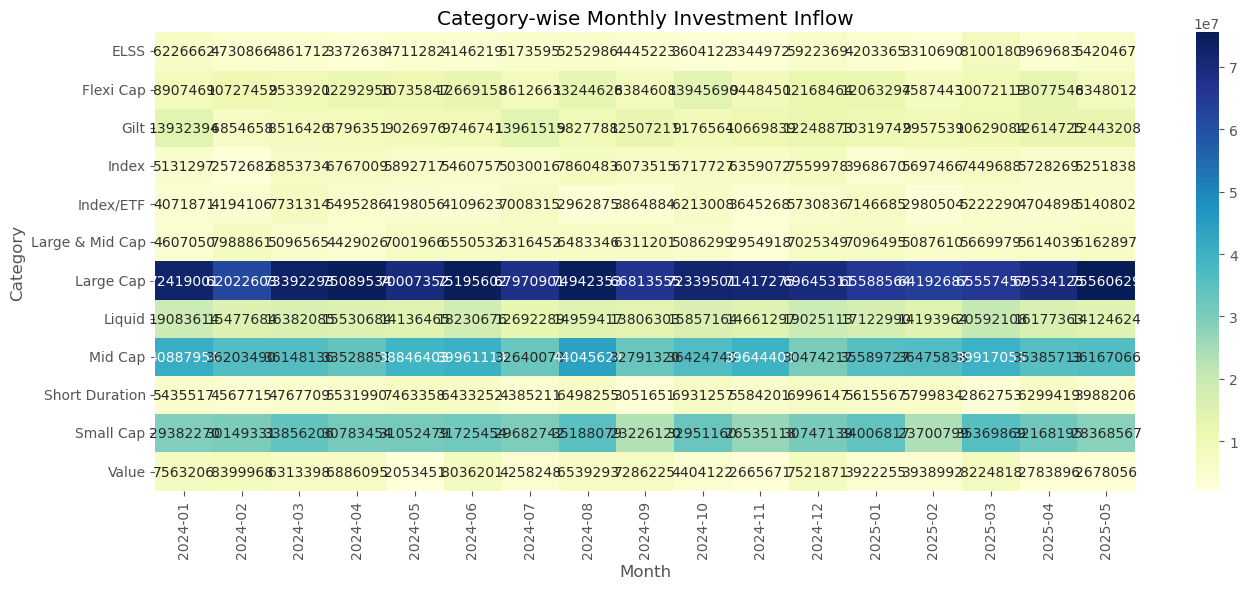

In [29]:
# Create Month column
heatmap_data["Month"] = heatmap_data["transaction_date"].dt.to_period("M").astype(str)

# Group by Category and Month
pivot = heatmap_data.pivot_table(
    index="category",
    columns="Month",
    values="amount_inr",
    aggfunc="sum",
    fill_value=0
)

# Plot Heatmap
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(14, 6))
sns.heatmap(pivot, cmap="YlGnBu", annot=True, fmt=".0f")

plt.title("Category-wise Monthly Investment Inflow")
plt.xlabel("Month")
plt.ylabel("Category")
plt.tight_layout()
plt.show()

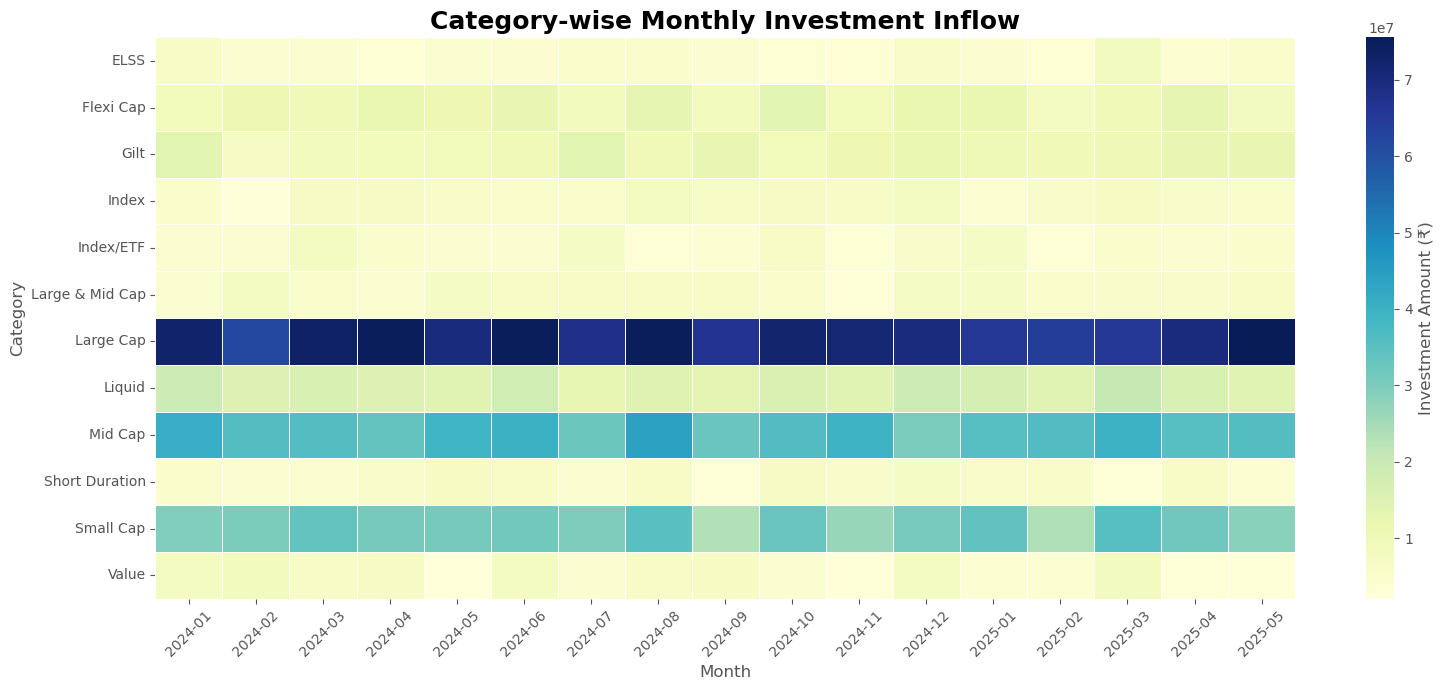

In [30]:
# ==========================
# Category-wise Monthly Investment Inflow Heatmap
# ==========================

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Ensure AMFI code is same datatype
transactions["amfi_code"] = transactions["amfi_code"].astype(str).str.strip()
performance["amfi_code"] = performance["amfi_code"].astype(str).str.strip()

# Merge transaction data with scheme performance
heatmap_data = transactions.merge(
    performance[["amfi_code", "category"]],
    on="amfi_code",
    how="left"
)

# Convert transaction date
heatmap_data["transaction_date"] = pd.to_datetime(
    heatmap_data["transaction_date"]
)

# Create Month column
heatmap_data["Month"] = heatmap_data["transaction_date"].dt.to_period("M").astype(str)

# Group by Category and Month
pivot = heatmap_data.groupby(
    ["category", "Month"]
)["amount_inr"].sum().unstack(fill_value=0)

# Sort categories alphabetically
pivot = pivot.sort_index()

# Plot Heatmap
plt.figure(figsize=(16,7))

sns.heatmap(
    pivot,
    cmap="YlGnBu",
    annot=False,          # Hide numbers (clean look)
    linewidths=0.5,
    linecolor="white",
    cbar_kws={"label": "Investment Amount (₹)"}
)

plt.title(
    "Category-wise Monthly Investment Inflow",
    fontsize=18,
    fontweight="bold"
)

plt.xlabel("Month", fontsize=12)
plt.ylabel("Category", fontsize=12)

plt.xticks(rotation=45)
plt.yticks(rotation=0)

plt.tight_layout()

plt.show()

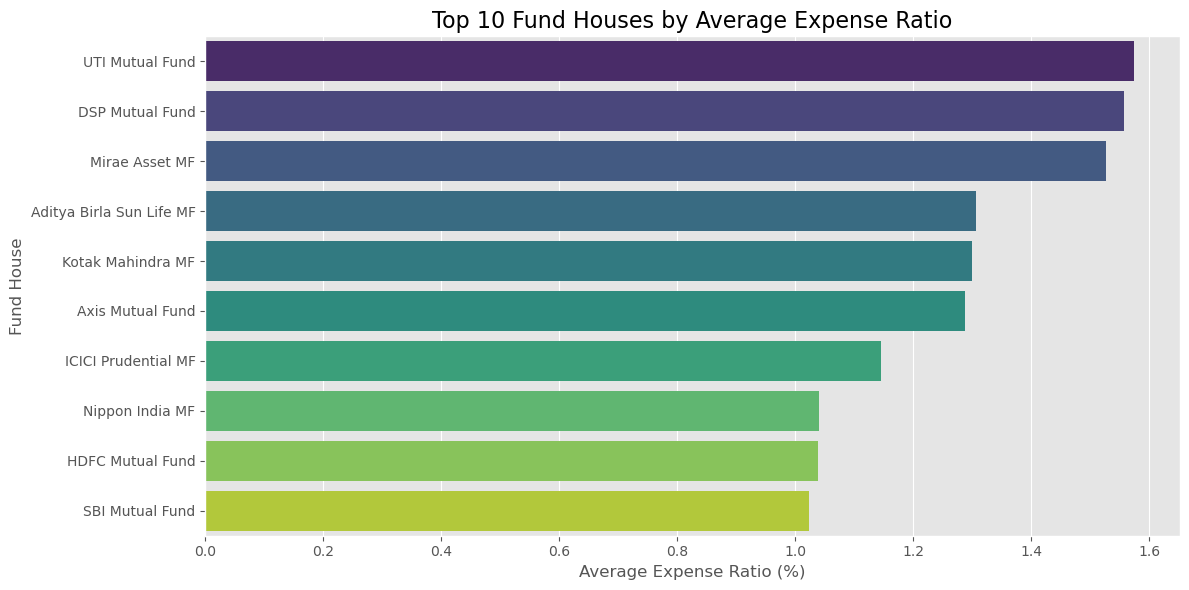

In [31]:
import matplotlib.pyplot as plt
import seaborn as sns

# Average expense ratio by fund house
expense = (
    performance.groupby("fund_house")["expense_ratio_pct"]
    .mean()
    .sort_values(ascending=False)
    .head(10)
)

plt.figure(figsize=(12,6))

sns.barplot(
    x=expense.values,
    y=expense.index,
    hue=expense.index,
    palette="viridis",
    legend=False
)

plt.title("Top 10 Fund Houses by Average Expense Ratio", fontsize=16)
plt.xlabel("Average Expense Ratio (%)")
plt.ylabel("Fund House")

plt.tight_layout()
plt.show()

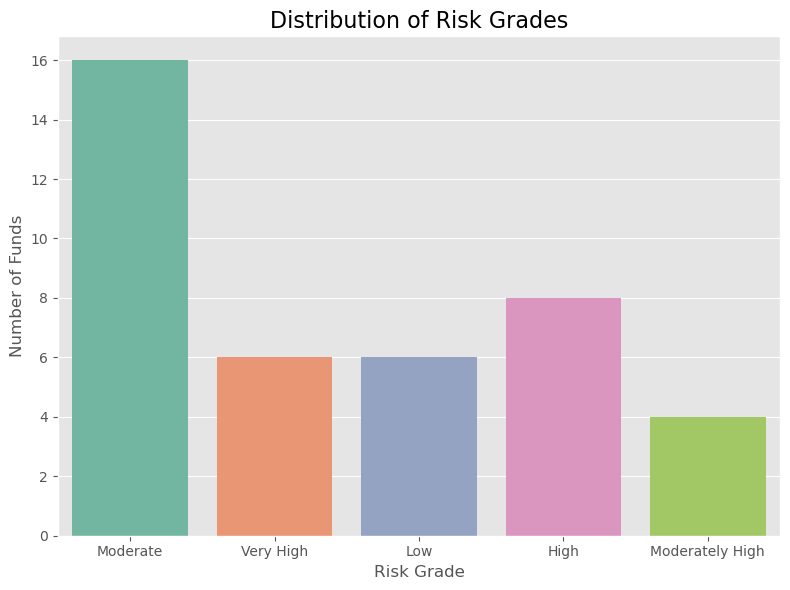

In [32]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,6))

sns.countplot(
    data=performance,
    x="risk_grade",
    hue="risk_grade",
    palette="Set2",
    legend=False
)

plt.title("Distribution of Risk Grades", fontsize=16)
plt.xlabel("Risk Grade")
plt.ylabel("Number of Funds")

plt.tight_layout()
plt.show()

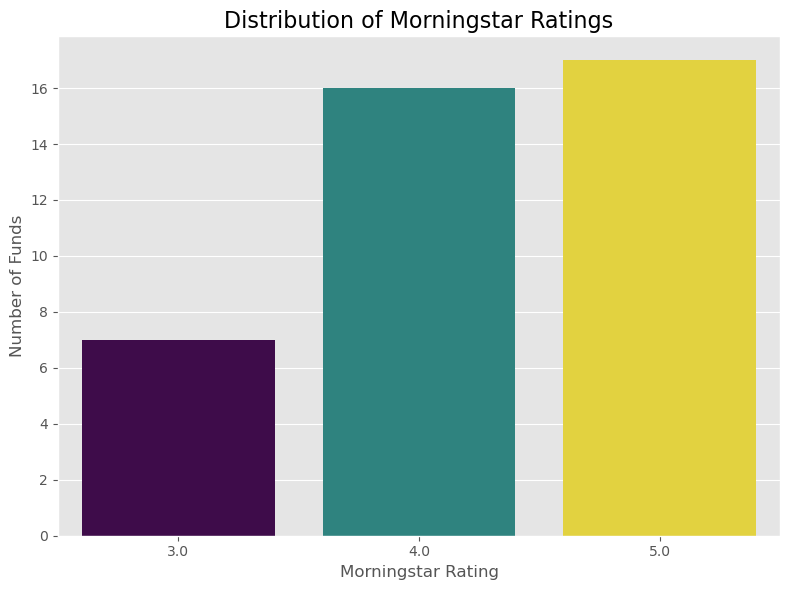

In [33]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,6))

sns.countplot(
    data=performance,
    x="morningstar_rating",
    hue="morningstar_rating",
    palette="viridis",
    legend=False
)

plt.title("Distribution of Morningstar Ratings", fontsize=16)
plt.xlabel("Morningstar Rating")
plt.ylabel("Number of Funds")

plt.tight_layout()
plt.show()

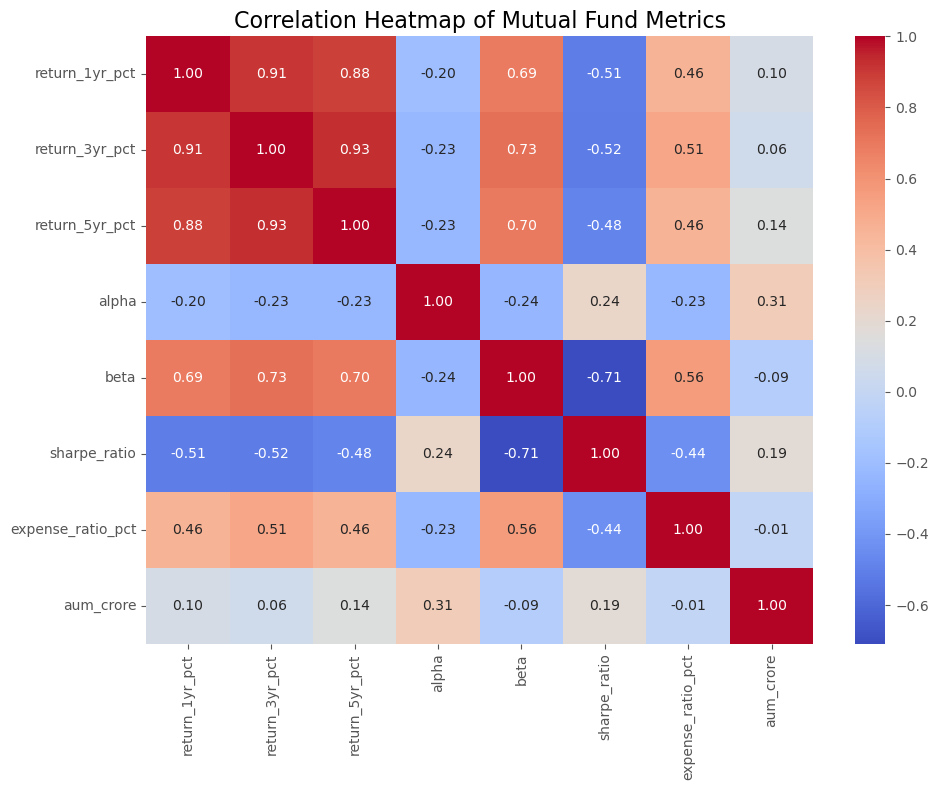

In [34]:
import matplotlib.pyplot as plt
import seaborn as sns

cols = [
    "return_1yr_pct",
    "return_3yr_pct",
    "return_5yr_pct",
    "alpha",
    "beta",
    "sharpe_ratio",
    "expense_ratio_pct",
    "aum_crore"
]

corr = performance[cols].corr()

plt.figure(figsize=(10,8))

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Heatmap of Mutual Fund Metrics", fontsize=16)

plt.tight_layout()
plt.show()

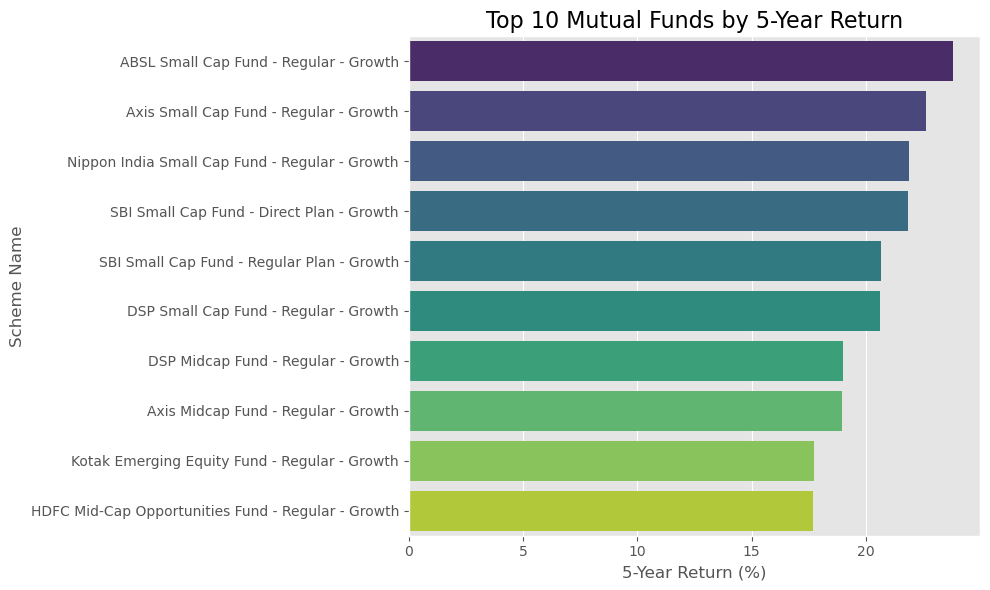

In [35]:
import matplotlib.pyplot as plt
import seaborn as sns

# Top 10 funds by 5-year return
top10 = performance.sort_values(
    by="return_5yr_pct",
    ascending=False
).head(10)

plt.figure(figsize=(10,6))

sns.barplot(
    data=top10,
    x="return_5yr_pct",
    y="scheme_name",
    hue="scheme_name",
    palette="viridis",
    legend=False
)

plt.title("Top 10 Mutual Funds by 5-Year Return", fontsize=16)
plt.xlabel("5-Year Return (%)")
plt.ylabel("Scheme Name")

plt.tight_layout()
plt.show()

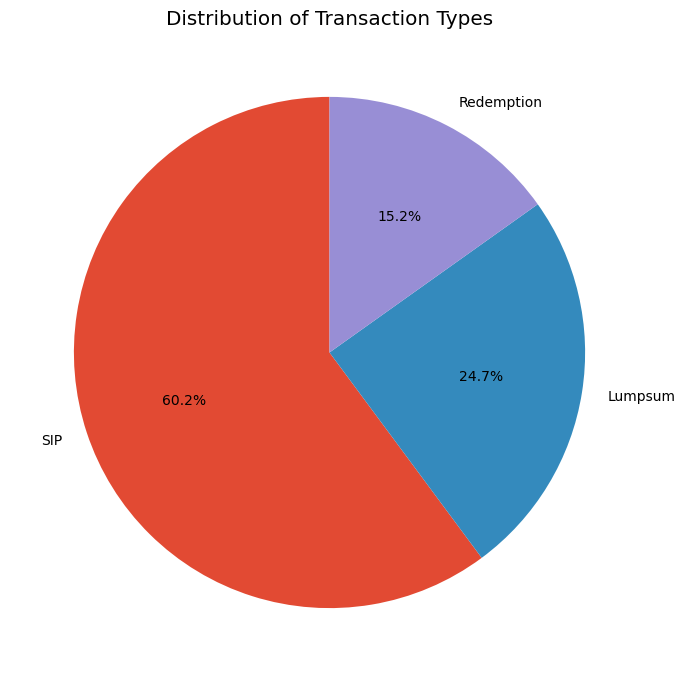

In [36]:
import matplotlib.pyplot as plt

transaction_counts = transactions["transaction_type"].value_counts()

plt.figure(figsize=(7,7))

plt.pie(
    transaction_counts,
    labels=transaction_counts.index,
    autopct="%1.1f%%",
    startangle=90
)

plt.title("Distribution of Transaction Types")

plt.tight_layout()
plt.show()

# EDA Summary

## Key Findings

- NAV values showed stable growth over the observed period.
- Large Cap funds attracted the highest investment inflows.
- SIP is the most common investment method.
- Expense ratios vary across fund houses.
- Most mutual funds fall under Medium and High risk categories.
- Higher Morningstar ratings are associated with better-performing funds.
- Long-term returns show positive correlation with Sharpe Ratio.
- Top-performing funds generated strong 5-year returns.
- Large Cap funds consistently received the highest monthly investments.
- These insights can help investors compare mutual funds based on risk, return, expenses, and investment patterns.